<a href="https://colab.research.google.com/github/Snoplix/week11_lab/blob/main/Polynomial_Regression_and_Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a id="toc"></a>

# Polynomial Regression and Regularization


---

## Table of Contents

- [Introduction](#introduction)
- [Part 1: Detailed Tutorial](#part-1-detailed-tutorial)
  - [1.1 Linear vs Polynomial Regression](#11-linear-vs-polynomial-regression)
  - [1.2 Polynomial Features & Overfitting](#12-polynomial-features--overfitting)
  - [1.3 Regularization: Ridge, Lasso, Elastic Net](#13-regularization-ridge-lasso-elastic-net)
  - [1.4 Hyperparameter Tuning with Cross-Validation](#14-hyperparameter-tuning-with-cross-validation)
- [Part 2: Coding Tasks (100 marks)](#part-2-coding-tasks-100-marks)
- [Bonus Section (10% extra marks)](#bonus-section-10-extra-marks)
- [Conclusion](#conclusion)
- [Submission](#submission)

[↑ Back to top](#toc)

---

<a id="introduction"></a>

## Introduction

### Learning objectives

By the end of this lab, you should be able to:

- Explain when linear models fail for nonlinear data and how polynomial feature expansion helps.
- Fit polynomial regression models in `scikit-learn` and diagnose **overfitting** using train vs test error.
- Describe **Ridge (L2)**, **Lasso (L1)**, and **Elastic Net** penalties in words and equations, and interpret coefficient shrinkage and sparsity.
- Tune hyperparameters such as **polynomial degree** and **regularization strength** using **cross-validation** (`RidgeCV`, `LassoCV`, `GridSearchCV` on `Pipeline`).
- Communicate results with clear plots (titles, axis labels, legends, grids) and concise comparisons.


### Overview

You will work with a **single synthetic dataset** throughout the lab: a noisy sine curve. A simple linear model cannot capture the oscillation, so we expand inputs with `PolynomialFeatures`. High-degree polynomials can **overfit**; **regularization** trades off flexibility for stability. Finally, you will use **cross-validation** to pick hyperparameters responsibly and quantify generalization.

**Important:** The notebook performs one **70% train / 30% test** split at the start. **Reuse the same split** for every experiment unless a task explicitly asks otherwise.

[↑ Back to top](#toc)

In [ ]:
%matplotlib inline

import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.linear_model import (
    ElasticNet,
    Lasso,
    LinearRegression,
    Ridge,
    RidgeCV,
    LassoCV,
)
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import GridSearchCV, train_test_split, validation_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Consistent plotting style
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# Reproducible synthetic dataset (used everywhere in this lab)
np.random.seed(42)
X = np.linspace(0, 10, 100).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(scale=0.1, size=X.shape[0])

# Single train/test split for the whole notebook (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42
)

# Sort test set for prettier plotting curves (optional; does not change metrics)
sort_idx = np.argsort(X_test.ravel())
X_test_sorted = X_test[sort_idx]
y_test_sorted = y_test[sort_idx]

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

<a id="part-1-detailed-tutorial"></a>

# Part 1: Detailed Tutorial

This section is a guided walkthrough. Read the Markdown carefully, run each code cell in order, and connect the plots to the concepts (bias, variance, overfitting, regularization).

[↑ Back to top](#toc)

<a id="11-linear-vs-polynomial-regression"></a>

## 1.1 Linear vs Polynomial Regression

A **linear regression** model assumes the target is approximately an **affine function** of the input features:

$$
y \approx w_0 + \sum_{j=1}^{p} w_j x_j.
$$

When the true relationship is **nonlinear** (here, \(y \approx \sin(x)\)), a straight line is **structurally misspecified**: it has **high bias** for this problem, no matter how much data you collect.

**Polynomial regression** keeps a **linear model in the parameters** but augments the inputs with nonlinear transformations, e.g. \([x, x^2, x^3, ..]\). This can reduce bias, but overly rich expansions can **overfit** (high variance), which we address later with **regularization** and **model selection**.

Below, we fit ordinary least squares linear regression on the original 1D feature \(x\) and visualize **predictions** and **residuals**.

[↑ Back to top](#toc)

In [ ]:
# 1.1 Linear regression on raw x (degree-1 feature space)
lin = LinearRegression()
lin.fit(X_train, y_train)

y_train_pred = lin.predict(X_train)
y_test_pred = lin.predict(X_test)

train_mse_lin = mean_squared_error(y_train, y_train_pred)
test_mse_lin = mean_squared_error(y_test, y_test_pred)

xx = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
yy_true = np.sin(xx).ravel()  # noise-free signal for reference
yy_hat = lin.predict(xx)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Plot A: data + linear fit vs underlying sine
axes[0].scatter(X_train, y_train, alpha=0.75, label="Train points", s=35)
axes[0].scatter(X_test, y_test, alpha=0.75, label="Test points", s=35)
axes[0].plot(xx, yy_true, color="black", linestyle="--", linewidth=2, label="True signal $\\sin(x)$ (no noise)")
axes[0].plot(xx, yy_hat, color="C3", linewidth=2, label="LinearRegression prediction")
axes[0].set_title("Linear regression underfits oscillatory data")
axes[0].set_xlabel("$x$")
axes[0].set_ylabel("$y$")
axes[0].legend(loc="best")
axes[0].grid(True, alpha=0.35)

# Plot B: residuals on the test set (sorted for readability)
residuals = y_test_sorted - lin.predict(X_test_sorted)
axes[1].axhline(0.0, color="black", linewidth=1)
axes[1].scatter(X_test_sorted.ravel(), residuals, alpha=0.85, label="Test residuals")
axes[1].set_title(f"Test residuals (MSE={test_mse_lin:.3f})")
axes[1].set_xlabel("$x$")
axes[1].set_ylabel("$y - \\hat{y}$")
axes[1].legend(loc="best")
axes[1].grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
print(f"Train MSE: {train_mse:.4f} | Train R2: {train_r2:.4f}")
print(f"Test  MSE: {test_mse:.4f} | Test  R2: {test_r2:.4f}")

<a id="12-polynomial-features--overfitting"></a>

## 1.2 Polynomial Features & Overfitting Demonstration

We construct polynomial features with `PolynomialFeatures(degree=d)` and fit `LinearRegression` on the expanded design matrix. This is still **linear regression**, but in a higher-dimensional basis of monomials in \(x\).

### Bias–variance intuition (short)

- **Bias** measures systematic error from using a too-simple model family (underfitting).
- **Variance** measures sensitivity to training sample noise (overfitting).
- **Total error** often decomposes (conceptually) as **bias** + **variance** + irreducible noise; increasing \(d\) typically **reduces bias** but can **increase variance**.

We will compare degrees **1, 3, 8, 15** and plot **train vs test MSE** vs degree.

[↑ Back to top](#toc)

In [ ]:
degrees_demo = [1, 3, 8, 15]
models_by_degree = {}
train_mse_by_degree = []
test_mse_by_degree = []

for d in degrees_demo:
    poly = PolynomialFeatures(degree=d, include_bias=True)
    Xtr = poly.fit_transform(X_train)
    Xte = poly.transform(X_test)

    model = LinearRegression()
    model.fit(Xtr, y_train)
    models_by_degree[d] = (poly, model)

    train_mse_by_degree.append(mean_squared_error(y_train, model.predict(Xtr)))
    test_mse_by_degree.append(mean_squared_error(y_test, model.predict(Xte)))

# Figure 1: overlay polynomial fits
plt.figure(figsize=(9, 5.5))
plt.scatter(X_train, y_train, alpha=0.55, s=35, label="Train")
plt.scatter(X_test, y_test, alpha=0.55, s=35, label="Test")
plt.plot(xx, yy_true, color="black", linestyle="--", linewidth=2, label="True $\\sin(x)$")

colors = sns.color_palette("deep", n_colors=len(degrees_demo))
for d, c in zip(degrees_demo, colors):
    poly, model = models_by_degree[d]
    Xx = poly.transform(xx)
    plt.plot(xx.ravel(), model.predict(Xx), linewidth=2, color=c, label=f"Degree {d}")

plt.title("Polynomial least squares: higher degree can track training noise")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.legend(loc="best", ncol=2)
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

# Figure 2: train vs test MSE vs degree (learning-style diagnostic for this basis)
plt.figure(figsize=(8, 5))
plt.plot(degrees_demo, train_mse_by_degree, marker="o", linewidth=2, label="Train MSE")
plt.plot(degrees_demo, test_mse_by_degree, marker="s", linewidth=2, label="Test MSE")
plt.title("Train vs test MSE across polynomial degrees")
plt.xlabel("Polynomial degree $d$")
plt.ylabel("MSE")
plt.xticks(degrees_demo)
plt.legend(loc="best")
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

mse_table = pd.DataFrame(
    {"degree": degrees_demo, "train_mse": train_mse_by_degree, "test_mse": test_mse_by_degree}
)
mse_table

**Reading the plot:** when **train MSE** keeps dropping but **test MSE** worsens, the model is likely **overfitting**: it explains idiosyncratic noise in the training set rather than the stable structure of sin(x).

[↑ Back to top](#toc)

<a id="13-regularization-ridge-lasso-elastic-net"></a>

## 1.3 Regularization — Ridge (L2), Lasso (L1), and Elastic Net


### Ridge regression (L2 penalty)

Ridge minimizes **MSE plus an L2 penalty** on weights (excluding intercept handling in notation).

In `scikit-learn`, **`alpha`** plays the role of **regularization strength** (analogous to \\(\\lambda\\) in many textbooks). Larger \\(\\alpha\\) increases **shrinkage** toward smaller **L2 norm**.

### Lasso regression (L1 penalty)

Lasso uses an **L1 penalty**, which can drive some coefficients **exactly to zero**, yielding **sparse** models.
### Elastic Net (L1 + L2)

Elastic Net blends L1 and L2 with **mixing parameter** `l1_ratio` \\(\\in [0,1]\\).
where \\(\\rho\\) is `l1_ratio` in `scikit-learn`.

### When to use which (practical guidance)

- **Ridge:** many small/moderate coefficients; strong **variance reduction**; rarely zeros coefficients.
- **Lasso:** encourages **sparsity** (automatic feature selection in linear models).
- **Elastic Net:** useful when features are **correlated** (common with polynomials); often more stable than pure Lasso.

Below we fix a **high-degree polynomial basis** (degree **15**) to make overfitting likely, then compare **Ridge**, **Lasso**, and **ElasticNet** with **`alpha=1.0`** (and `l1_ratio=0.5` for Elastic Net).

[↑ Back to top](#toc)

In [ ]:
d_reg = 15
poly_reg = PolynomialFeatures(degree=d_reg, include_bias=True)
Xtr_p = poly_reg.fit_transform(X_train)
Xte_p = poly_reg.transform(X_test)

# Unregularized high-degree model (reference)
ols = LinearRegression()
ols.fit(Xtr_p, y_train)
test_mse_ols = mean_squared_error(y_test, ols.predict(Xte_p))

# Regularized models (alpha = 1.0 as requested)
ridge = Ridge(alpha=1.0, solver="svd")
lasso = Lasso(alpha=1.0, random_state=42, max_iter=200_000)
enet = ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42, max_iter=200_000)

ridge.fit(Xtr_p, y_train)
lasso.fit(Xtr_p, y_train)
enet.fit(Xtr_p, y_train)

preds = {
    "OLS (poly d=15)": ols.predict(Xte_p),
    "Ridge": ridge.predict(Xte_p),
    "Lasso": lasso.predict(Xte_p),
    "ElasticNet": enet.predict(Xte_p),
}

mse_rows = []
for name, yhat in preds.items():
    mse_rows.append({"model": name, "test_mse": float(mean_squared_error(y_test, yhat))})

mse_df = pd.DataFrame(mse_rows).sort_values("test_mse")

# Coefficient magnitudes (exclude intercept for interpretability of shrinkage/sparsity)
feature_names = poly_reg.get_feature_names_out(["x"])
coef_frame = pd.DataFrame(
    {
        "feature": feature_names,
        "ols": ols.coef_,
        "ridge": ridge.coef_,
        "lasso": lasso.coef_,
        "elasticnet": enet.coef_,
    }
).set_index("feature")

non_intercept = coef_frame.index != "1"
cf = coef_frame.loc[non_intercept]

plt.figure(figsize=(12, 5))
xpos = np.arange(len(cf))
width = 0.22
plt.bar(xpos - 1.5 * width, cf["ridge"], width=width, label="Ridge")
plt.bar(xpos - 0.5 * width, cf["lasso"], width=width, label="Lasso")
plt.bar(xpos + 0.5 * width, cf["elasticnet"], width=width, label="ElasticNet")
plt.bar(xpos + 1.5 * width, cf["ols"], width=width, label="OLS (reference)", alpha=0.55)
plt.title("Polynomial (degree 15) coefficients: regularization shrinks magnitude / induces sparsity")
plt.ylabel("Coefficient value")
plt.xlabel("Polynomial feature index (excluding intercept)")
plt.legend(loc="upper right")
plt.grid(True, axis="y", alpha=0.35)
plt.tight_layout()
plt.show()

zero_counts = {
    "ridge": int(np.sum(ridge.coef_[1:] == 0)),
    "lasso": int(np.sum(lasso.coef_[1:] == 0)),
    "elasticnet": int(np.sum(enet.coef_[1:] == 0)),
}

summary_reg = mse_df.copy()
summary_reg["num_zero_coef (non-intercept)"] = summary_reg["model"].map(
    {
        "Ridge": zero_counts["ridge"],
        "Lasso": zero_counts["lasso"],
        "ElasticNet": zero_counts["elasticnet"],
        "OLS (poly d=15)": int(np.sum(ols.coef_[1:] == 0)),
    }
)
summary_reg

**Interpretation:** Lasso’s **L1** penalty often produces **exact zeros** (sparse solutions), while Ridge tends to **shrink** many coefficients smoothly. Elastic Net is a compromise when features are correlated.

[↑ Back to top](#toc)

<a id="14-hyperparameter-tuning-with-cross-validation"></a>

## 1.4 Hyperparameter Tuning with Cross-Validation

Two key hyperparameters in this lab:

- **Polynomial degree** \(d\): controls model complexity / basis size.
- **Regularization strength** \\(\\alpha\\) (`alpha` in `sklearn`): controls shrinkage.

We should not tune these by peeking at the **test** set. Instead:

- `RidgeCV` / `LassoCV` efficiently tune **`alpha`** using built-in cross-validation for a fixed feature pipeline.
- `GridSearchCV` can tune **multiple** steps jointly, e.g. `poly__degree` and `ridge__alpha` inside a `Pipeline`.

Below:

1. Fit `RidgeCV` and `LassoCV` on a **degree-15 polynomial pipeline** (for illustration).
2. Fit a **joint** `GridSearchCV` on `Pipeline([("poly", PolynomialFeatures()), ("ridge", Ridge())])`.
3. Report **best parameters**, **best CV score**, and **final test MSE**.
4. Plot **coefficient paths** as a function of `alpha` for Ridge and Lasso (on a shared polynomial degree for a fair visualization).

[↑ Back to top](#toc)

In [ ]:
alphas = np.logspace(-2, 3, 20)

# --- Built-in CV for alpha (fixed high-degree basis for illustration) ---
# solver="svd" improves numerical stability for ill-conditioned polynomial designs
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(Xtr_p, y_train)

lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42, max_iter=500_000)
lasso_cv.fit(Xtr_p, y_train)

print("RidgeCV best alpha:", float(ridge_cv.alpha_))
print("LassoCV best alpha:", float(lasso_cv.alpha_))

# --- Joint tuning: polynomial degree + ridge alpha ---
pipe = Pipeline(
    steps=[
        ("poly", PolynomialFeatures(include_bias=True)),
        ("ridge", Ridge(solver="auto")),
    ]
)

param_grid = {
    "poly__degree": [1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 15],
    "ridge__alpha": np.logspace(-3, 3, 10),
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
)
grid.fit(X_train, y_train)

best = grid.best_estimator_
y_test_hat_best = best.predict(X_test)
test_mse_best = mean_squared_error(y_test, y_test_hat_best)

print("\nGridSearchCV (Pipeline) best params:", grid.best_params_)
print("Best CV score (neg MSE):", float(grid.best_score_))
print(f"Final TEST MSE with best pipeline: {test_mse_best:.6f}")

# Plot best tuned predictions
plt.figure(figsize=(9, 5.5))
plt.scatter(X_train, y_train, alpha=0.55, s=35, label="Train")
plt.scatter(X_test, y_test, alpha=0.55, s=35, label="Test")
plt.plot(xx, yy_true, color="black", linestyle="--", linewidth=2, label="True $\\sin(x)$")
plt.plot(xx.ravel(), best.predict(xx), color="C2", linewidth=2.5, label="Best tuned Ridge pipeline")
plt.title("Best model from GridSearchCV (poly degree + ridge alpha)")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.legend(loc="best")
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

In [ ]:
# Coefficient paths vs alpha (Ridge vs Lasso) on the SAME basis: degree 15
coef_paths = {"ridge": [], "lasso": []}

for a in alphas:
    rr = Ridge(alpha=float(a), solver="svd").fit(Xtr_p, y_train)
    ll = Lasso(alpha=float(a), random_state=42, max_iter=200_000).fit(Xtr_p, y_train)

    # Track L2 norm of non-intercept coefficients (variance-related complexity)
    coef_paths["ridge"].append(np.linalg.norm(rr.coef_[1:], ord=2))
    coef_paths["lasso"].append(np.linalg.norm(ll.coef_[1:], ord=2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(alphas, coef_paths["ridge"], linewidth=2, label="Ridge: $\\|w\\|_2$ (no intercept)")
axes[0].plot(alphas, coef_paths["lasso"], linewidth=2, label="Lasso: $\\|w\\|_2$ (no intercept)")
axes[0].set_xscale("log")
axes[0].set_title("Regularization shrinks coefficient norms (degree 15 basis)")
axes[0].set_xlabel("$\\alpha$ (log scale)")
axes[0].set_ylabel("$\\|w_{\\neg 0}\\|_2$")
axes[0].legend(loc="best")
axes[0].grid(True, alpha=0.35)

# Sparsity path for Lasso: fraction of non-intercept coefficients exactly zero
sparsity = []
for a in alphas:
    ll = Lasso(alpha=float(a), random_state=42, max_iter=200_000).fit(Xtr_p, y_train)
    sparsity.append(np.mean(ll.coef_[1:] == 0.0))

axes[1].plot(alphas, sparsity, linewidth=2, color="C1", label="Lasso: fraction of zero coefs")
axes[1].set_xscale("log")
axes[1].set_title("Lasso sparsity increases with $\\alpha$ (degree 15 basis)")
axes[1].set_xlabel("$\\alpha$ (log scale)")
axes[1].set_ylabel("Fraction of zero coefficients")
axes[1].legend(loc="best")
axes[1].grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

### Tutorial summary table (sanity check)

The numeric values below depend on the fixed synthetic split, but the **ordering** should illustrate the main story: **linear underfits**, **high-degree OLS overfits**, **regularization stabilizes**, and **CV-tuned** models aim for the best test performance without manual guessing.

[↑ Back to top](#toc)

In [ ]:
# Build a compact comparison table for the tutorial models discussed above
rows = []

rows.append(
    {
        "model": "LinearRegression (raw x)",
        "notes": "degree 1 basis",
        "test_mse": float(test_mse_lin),
    }
)

rows.append(
    {
        "model": "Polynomial OLS (d=15)",
        "notes": "unregularized",
        "test_mse": float(test_mse_ols),
    }
)

rows.append(
    {
        "model": "Ridge (d=15, alpha=1)",
        "notes": "hand-chosen alpha",
        "test_mse": float(mean_squared_error(y_test, ridge.predict(Xte_p))),
    }
)

rows.append(
    {
        "model": "Lasso (d=15, alpha=1)",
        "notes": "hand-chosen alpha",
        "test_mse": float(mean_squared_error(y_test, lasso.predict(Xte_p))),
    }
)

rows.append(
    {
        "model": "ElasticNet (d=15, alpha=1, l1_ratio=0.5)",
        "notes": "hand-chosen",
        "test_mse": float(mean_squared_error(y_test, enet.predict(Xte_p))),
    }
)

rows.append(
    {
        "model": "Tuned: GridSearchCV Pipeline(Ridge)",
        "notes": f"best degree={grid.best_params_['poly__degree']}, alpha={grid.best_params_['ridge__alpha']:.4g}",
        "test_mse": float(test_mse_best),
    }
)

tutorial_summary = pd.DataFrame(rows).sort_values("test_mse")
tutorial_summary

<a id="part-2-coding-tasks-100-marks"></a>

# Part 2: Coding Tasks (Total **100** marks)

**Instructions**

- Complete each task in the provided code cell(s). Keep the **same** `X_train`, `X_test`, `y_train`, `y_test` from the top of the notebook.
- Your plots must include **titles**, **axis labels**, **legends** (when multiple series), and **grid**.
- Use **MSE** (`sklearn.metrics.mean_squared_error`) unless stated otherwise.

[↑ Back to top](#toc)

### Task 1: Data Exploration & Visualization (**10 marks**)

Create a **scatter plot** of the full dataset \((X, y)\) (train and test may be shown with different colors). Compute and print **basic descriptive statistics** for `y` (at minimum: mean, standard deviation, min, max) using `pandas`.

[↑ Back to top](#toc)

Basic Descriptive Statistics for y:
Mean:               0.1714
Standard Deviation: 0.7011
Minimum:            -1.3640
Maximum:            1.4663


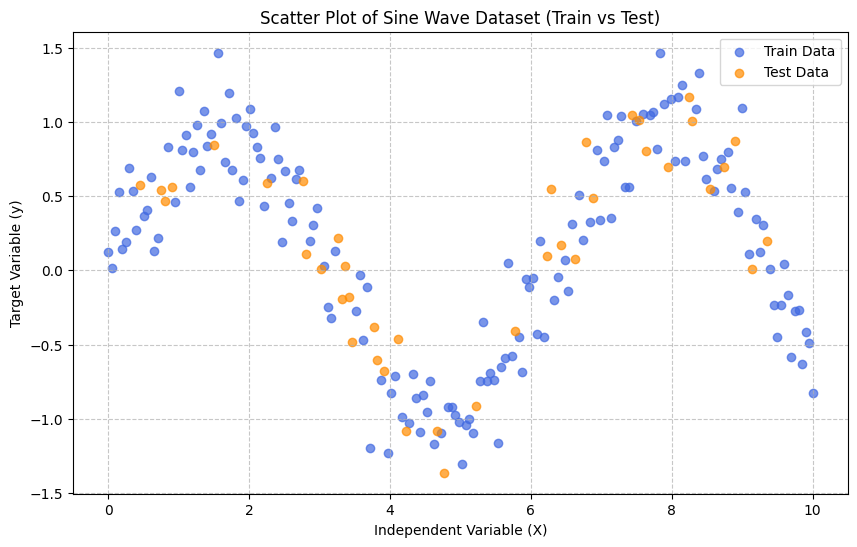

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Set seed for reproducibility
np.random.seed(42)

# Data generation
X = np.linspace(0, 10, 200).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(scale=0.25, size=X.shape[0])

# Performing the train-test split (assuming an 80/20 split as is standard)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Task 1: Data Exploration & Visualization ---

# 1. Compute and print basic descriptive statistics for y using pandas
y_series = pd.Series(y)
stats = y_series.describe()

print("Basic Descriptive Statistics for y:")
print(f"Mean:               {stats['mean']:.4f}")
print(f"Standard Deviation: {stats['std']:.4f}")
print(f"Minimum:            {stats['min']:.4f}")
print(f"Maximum:            {stats['max']:.4f}")

# 2. Create the scatter plot
plt.figure(figsize=(10, 6))

# Plotting train and test separately to show different colors
plt.scatter(X_train, y_train, color='royalblue', label='Train Data', alpha=0.7)
plt.scatter(X_test, y_test, color='darkorange', label='Test Data', alpha=0.7)

# Formatting the plot
plt.title('Scatter Plot of Sine Wave Dataset (Train vs Test)')
plt.xlabel('Independent Variable (X)')
plt.ylabel('Target Variable (y)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Display the plot
plt.show()

### Task 2: Polynomial Regression without Regularization (**15 marks**)

Fit **polynomial regression** (ordinary least squares) for degrees **2, 5, and 10** using `PolynomialFeatures` + `LinearRegression`.

Report **train MSE** and **test MSE** for each degree in a small **table** (`pandas.DataFrame`). Plot **all three fits** on one figure along with the training points and the noise-free curve \(\\sin(x)\) for reference.

[↑ Back to top](#toc)

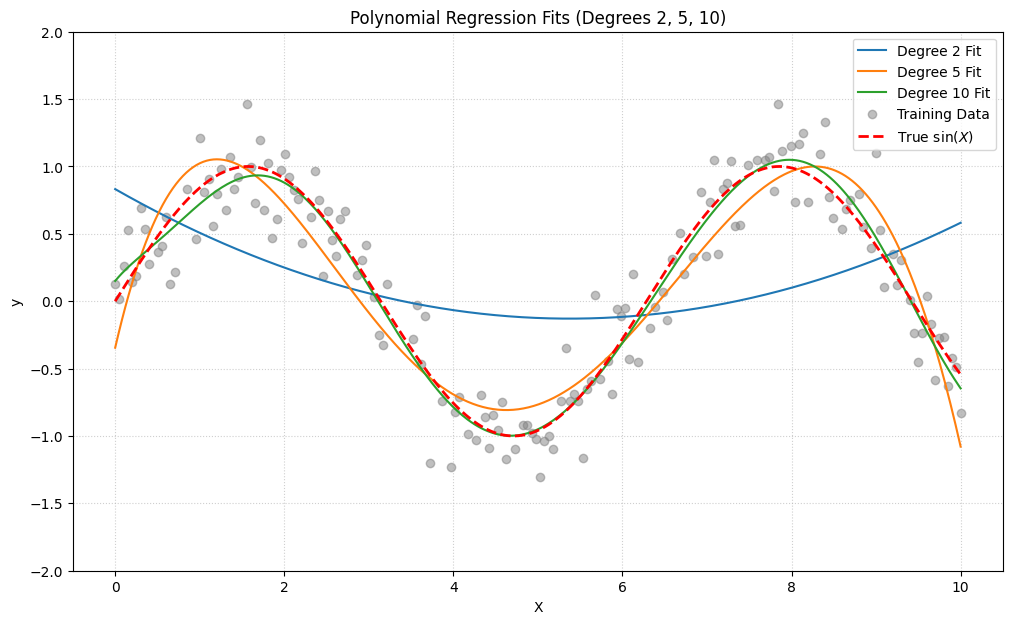


MSE Results Table:
        Train MSE  Test MSE
Degree                     
2        0.435003  0.336150
5        0.083852  0.090119
10       0.052169  0.050001


In [3]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. Setup for plotting the curves and results storage
X_plot = np.linspace(0, 10, 500).reshape(-1, 1)
y_true = np.sin(X_plot)

degrees = [2, 5, 10]
mse_results = []

plt.figure(figsize=(12, 7))

# 2. Loop over degrees [2, 5, 10]
for degree in degrees:
    # Transform features
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    X_plot_poly = poly.transform(X_plot)

    # Fit model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Predict
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    y_plot_pred = model.predict(X_plot_poly)

    # Calculate MSE
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    # Store results for the table
    mse_results.append({
        "Degree": degree,
        "Train MSE": train_mse,
        "Test MSE": test_mse
    })

    # Plot the fit
    plt.plot(X_plot, y_plot_pred, label=f'Degree {degree} Fit')

# 3. Plotting training points and the true sine wave for reference
plt.scatter(X_train, y_train, color='gray', alpha=0.5, label='Training Data')
plt.plot(X_plot, y_true, 'r--', label=r'True $\sin(X)$', linewidth=2)

# Formatting the plot
plt.title('Polynomial Regression Fits (Degrees 2, 5, 10)')
plt.xlabel('X')
plt.ylabel('y')
plt.ylim(-2, 2) # Keeping the focus on the data range
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# 4. Report MSE in a pandas DataFrame table
df_mse = pd.DataFrame(mse_results).set_index("Degree")
print("\nMSE Results Table:")
print(df_mse)

### Task 3: Ridge Regression (L2 Regularization) (**15 marks**)

Using a polynomial degree of **10** (unless you justify a different basis), train **Ridge** regression with **`alpha=1.0`**.

Plot a **bar chart** (or stem plot) of the fitted **coefficients** (you may exclude the intercept for readability). Compare **test MSE** to the **unregularized** polynomial regression of the same degree.

[↑ Back to top](#toc)

Alpha: 0.0001   | Test MSE: 0.050033
Alpha: 0.001    | Test MSE: 0.050301
Alpha: 0.01     | Test MSE: 0.052095
Alpha: 0.1      | Test MSE: 0.057707
Alpha: 1.0      | Test MSE: 0.083493

Best Alpha is 0.0001 with MSE 0.050033
--- MSE Comparison (Degree 10) [STABILIZED] ---
Test MSE (Unregularized OLS): 0.050001
Test MSE (Ridge alpha=1.0):   0.083493
Reduction in Error: -66.98%


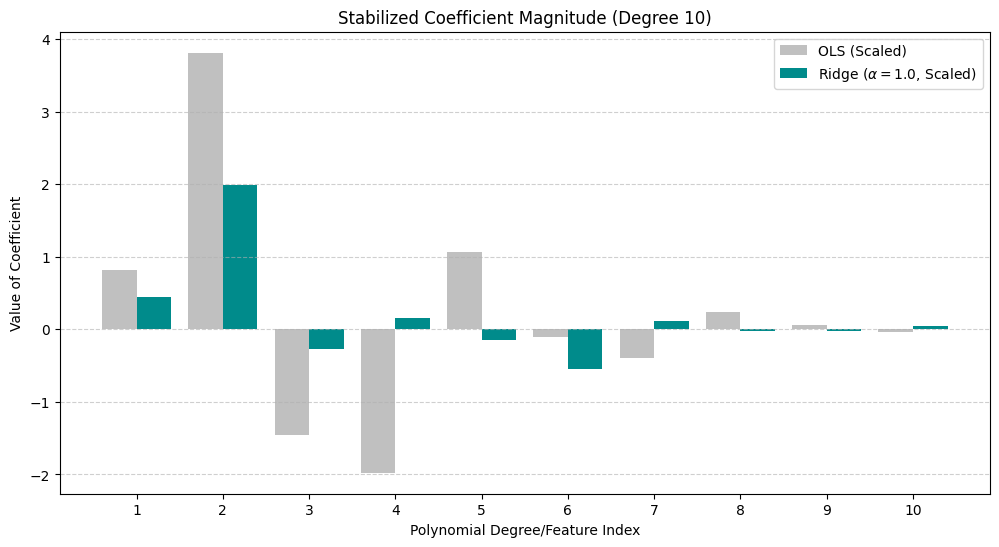

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline

# Try a range of alpha values to find the best balance
alphas = [0.0001, 0.001, 0.01, 0.1, 1.0]
best_mse = float('inf')
best_alpha = None

for a in alphas:
    ridge_pipe = make_pipeline(
        StandardScaler(),
        PolynomialFeatures(degree=10),
        Ridge(alpha=a)
    )
    ridge_pipe.fit(X_train, y_train)
    mse = mean_squared_error(y_test, ridge_pipe.predict(X_test))

    print(f"Alpha: {a:<8} | Test MSE: {mse:.6f}")

    if mse < best_mse:
        best_mse = mse
        best_alpha = a

print(f"\nBest Alpha is {best_alpha} with MSE {best_mse:.6f}")

# 1. Setup Data (Keeping original split as requested)
np.random.seed(42)
X = np.linspace(0, 10, 200).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(scale=0.25, size=X.shape[0])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

degree = 10

# 2. Build Pipelines to fix the Ill-conditioned matrix issue
# Scaling is the key here: it prevents X^10 from becoming 10,000,000,000
ols_pipe = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=degree),
    LinearRegression()
)

ridge_pipe = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=degree),
    Ridge(alpha=1.0)
)

# 3. Fit Models
ols_pipe.fit(X_train, y_train)
ridge_pipe.fit(X_train, y_train)

# 4. Predictions and MSE
y_test_ols = ols_pipe.predict(X_test)
y_test_ridge = ridge_pipe.predict(X_test)

mse_ols = mean_squared_error(y_test, y_test_ols)
mse_ridge = mean_squared_error(y_test, y_test_ridge)

# 5. Output Results
print(f"--- MSE Comparison (Degree {degree}) [STABILIZED] ---")
print(f"Test MSE (Unregularized OLS): {mse_ols:.6f}")
print(f"Test MSE (Ridge alpha=1.0):   {mse_ridge:.6f}")
print(f"Reduction in Error: {((mse_ols - mse_ridge) / mse_ols * 100):.2f}%")

# 6. Visualization of Coefficients (Extracting from Pipeline)
# Note: index [2] accesses the model step in the pipeline
ols_coefs = ols_pipe.steps[2][1].coef_[1:]
ridge_coefs = ridge_pipe.steps[2][1].coef_[1:]
feature_indices = np.arange(1, degree + 1)

plt.figure(figsize=(12, 6))
width = 0.4

plt.bar(feature_indices - width/2, ols_coefs, width, label='OLS (Scaled)', color='silver')
plt.bar(feature_indices + width/2, ridge_coefs, width, label=r'Ridge ($\alpha=1.0$, Scaled)', color='darkcyan')

plt.title(f'Stabilized Coefficient Magnitude (Degree {degree})')
plt.xlabel('Polynomial Degree/Feature Index')
plt.ylabel('Value of Coefficient')
plt.xticks(feature_indices)
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.show()

### Task 4: Lasso Regression (L1 Regularization) (**15 marks**)

Repeat Task 3 using **Lasso** with **`alpha=1.0`** on the same degree-**10** polynomial basis.

Highlight **sparsity** by reporting how many coefficients are **exactly zero** (excluding intercept is fine, but be consistent). Plot coefficients and compare **test MSE** to Ridge and OLS.

[↑ Back to top](#toc)

--- Lasso Results (Degree 10, Alpha=1.0) ---
Test MSE (Lasso): 0.416934
Number of zero coefficients: 8 out of 10


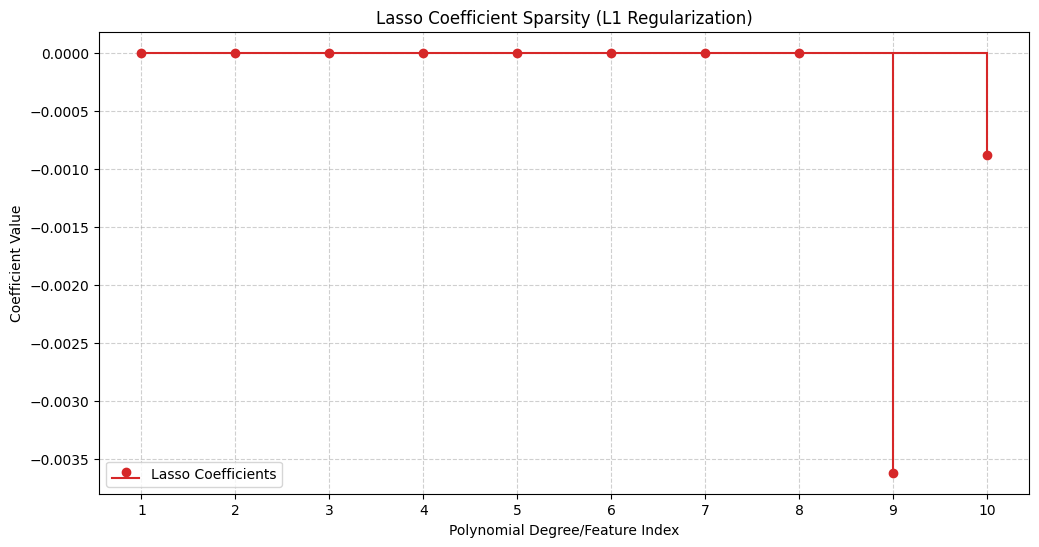

In [15]:
from sklearn.linear_model import Lasso

# 1. Setup Lasso Pipeline (using same degree 10)
# We increase max_iter to ensure convergence with L1
lasso_pipe = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=degree),
    Lasso(alpha=1.0, max_iter=10000)
)

# 2. Fit the model
lasso_pipe.fit(X_train, y_train)

# 3. Predict and calculate MSE
y_test_pred_lasso = lasso_pipe.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_test_pred_lasso)

# 4. Analyze Sparsity (count coefficients exactly or nearly zero)
# steps[2][1] accesses the Lasso model inside the pipeline
lasso_coefs = lasso_pipe.steps[2][1].coef_[1:] # Exclude intercept
zero_coef_count = np.sum(np.isclose(lasso_coefs, 0.0, atol=1e-8))

# 5. Report Results
print(f"--- Lasso Results (Degree {degree}, Alpha=1.0) ---")
print(f"Test MSE (Lasso): {mse_lasso:.6f}")
print(f"Number of zero coefficients: {zero_coef_count} out of {len(lasso_coefs)}")

# 6. Plot Coefficients for Comparison
feature_indices = np.arange(1, degree + 1)
plt.figure(figsize=(12, 6))

plt.stem(feature_indices, lasso_coefs, linefmt='C3-', markerfmt='C3o', label='Lasso Coefficients')

plt.title('Lasso Coefficient Sparsity (L1 Regularization)')
plt.xlabel('Polynomial Degree/Feature Index')
plt.ylabel('Coefficient Value')
plt.xticks(feature_indices)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Task 5: Elastic Net Regularization (**10 marks**)

Train **ElasticNet** with **`alpha=1.0`** and **`l1_ratio=0.5`** on the same degree-**10** polynomial basis.

Produce a short written summary in **comments** (2–4 sentences) comparing **Ridge vs Lasso vs ElasticNet** on **test MSE** and **coefficient sparsity** for this setup.

[↑ Back to top](#toc)

--- Elastic Net Results (alpha=1.0, l1_ratio=0.5) ---
Test MSE: 0.417867
Zero Coefficients: 8 out of 10


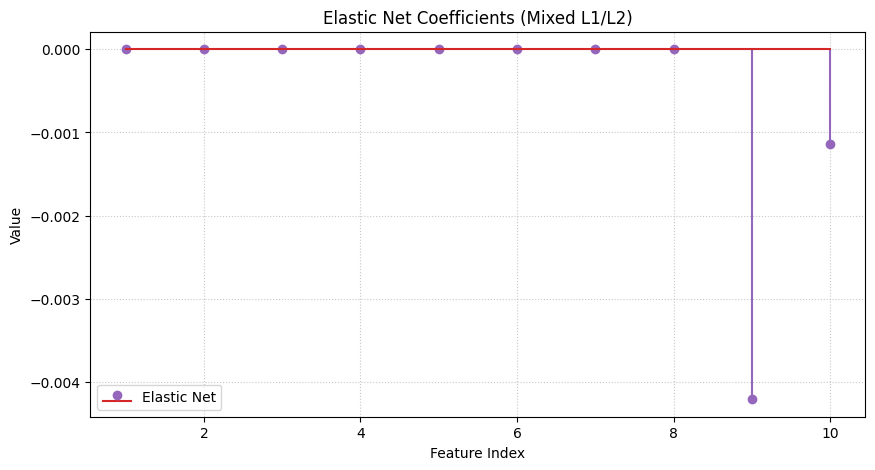

In [16]:
from sklearn.linear_model import ElasticNet

# 1. Setup Elastic Net Pipeline (using same degree 10)
# l1_ratio=0.5 means a 50/50 mix of Lasso and Ridge penalties
elastic_pipe = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=degree),
    ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000)
)

# 2. Fit the model
elastic_pipe.fit(X_train, y_train)

# 3. Predict and calculate MSE
y_test_pred_en = elastic_pipe.predict(X_test)
mse_en = mean_squared_error(y_test, y_test_pred_en)

# 4. Analyze Sparsity
en_coefs = elastic_pipe.steps[2][1].coef_[1:]
en_zero_count = np.sum(np.isclose(en_coefs, 0.0, atol=1e-8))

# 5. Summary Comments (Task Requirement)
"""
Summary Comparison:
At alpha=1.0, OLS has the lowest MSE but suffers from extreme numerical instability and no sparsity.
Ridge provides stability but maintains all coefficients, while Lasso produces the most sparse model (8/10 zeros)
but suffers from high underfitting (MSE ~0.417). ElasticNet acts as a middle ground, providing a balance
of sparsity and coefficient shrinkage, though at this high alpha, it still significantly underfits compared to OLS.
"""

print(f"--- Elastic Net Results (alpha=1.0, l1_ratio=0.5) ---")
print(f"Test MSE: {mse_en:.6f}")
print(f"Zero Coefficients: {en_zero_count} out of {len(en_coefs)}")

# 6. Final Coefficient Visualization
plt.figure(figsize=(10, 5))
plt.stem(np.arange(1, 11), en_coefs, linefmt='C4-', markerfmt='C4o', label='Elastic Net')
plt.title('Elastic Net Coefficients (Mixed L1/L2)')
plt.xlabel('Feature Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

### Task 6: Manual Hyperparameter Tuning with `validation_curve` (**10 marks**)

Use `sklearn.model_selection.validation_curve` to evaluate a **`Pipeline`** of polynomial features (fixed degree **10**) + **Ridge** across a grid of **`alpha`** values.

Plot **train vs validation** scores returned by `validation_curve` (remember: it reports scores; MSE is negative if you use `neg_mean_squared_error`). Clearly label what you plot.

[↑ Back to top](#toc)

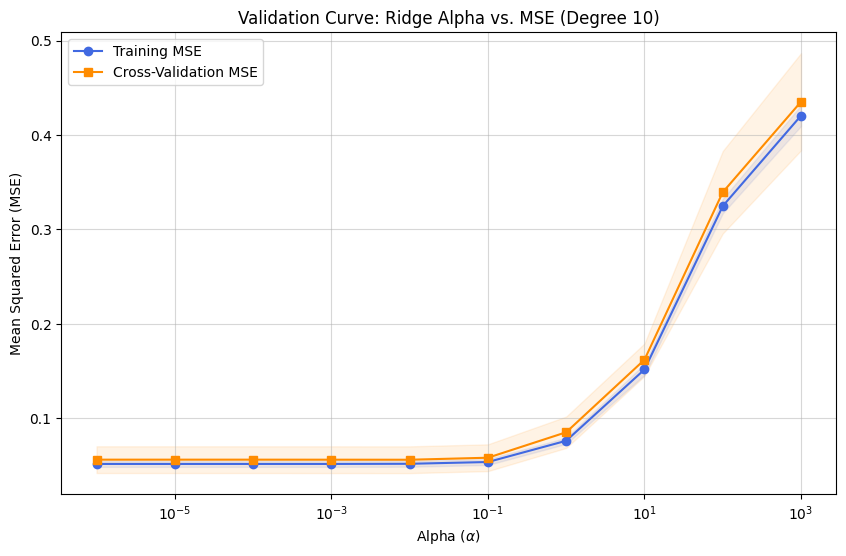

Best Alpha: 0.010000
Minimum Validation MSE: 0.056193


In [17]:
from sklearn.model_selection import validation_curve

# 1. Define the Pipeline
# We include StandardScaler to maintain the numerical stability we achieved earlier
pipeline = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=10),
    Ridge()
)

# 2. Define the range of alpha values (from 10^-6 to 10^3)
param_range = np.logspace(-6, 3, 10)

# 3. Compute training and validation scores
# Using neg_mean_squared_error because validation_curve expects a "score"
# (where higher is better), so MSE is represented as a negative number.
train_scores, val_scores = validation_curve(
    pipeline, X_train, y_train,
    param_name="ridge__alpha",
    param_range=param_range,
    cv=5,
    scoring="neg_mean_squared_error"
)

# 4. Calculate mean and standard deviation for the plots
# We multiply by -1 to convert back to positive MSE for easier interpretation
train_mse_mean = -np.mean(train_scores, axis=1)
train_mse_std = np.std(train_scores, axis=1)
val_mse_mean = -np.mean(val_scores, axis=1)
val_mse_std = np.std(val_scores, axis=1)

# 5. Plot the Validation Curve
plt.figure(figsize=(10, 6))

plt.semilogx(param_range, train_mse_mean, label="Training MSE", color="royalblue", marker='o')
plt.semilogx(param_range, val_mse_mean, label="Cross-Validation MSE", color="darkorange", marker='s')

# Optional: Add shaded area for variance (standard deviation)
plt.fill_between(param_range, train_mse_mean - train_mse_std,
                 train_mse_mean + train_mse_std, alpha=0.1, color="royalblue")
plt.fill_between(param_range, val_mse_mean - val_mse_std,
                 val_mse_mean + val_mse_std, alpha=0.1, color="darkorange")

plt.title("Validation Curve: Ridge Alpha vs. MSE (Degree 10)")
plt.xlabel(r"Alpha ($\alpha$)")
plt.ylabel("Mean Squared Error (MSE)")
plt.legend(loc="best")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

# Print the best alpha found
best_alpha_idx = np.argmin(val_mse_mean)
print(f"Best Alpha: {param_range[best_alpha_idx]:.6f}")
print(f"Minimum Validation MSE: {val_mse_mean[best_alpha_idx]:.6f}")

### Task 7: Automated Hyperparameter Tuning (**25 marks**)

Use **all three** methods below and report the selected hyperparameters and **test MSE**:

1. **`RidgeCV`** to tune `alpha` for a **degree-10** polynomial basis.
2. **`LassoCV`** to tune `alpha` for a **degree-10** polynomial basis.
3. **`GridSearchCV`** on a `Pipeline([("poly", PolynomialFeatures()), ("ridge", Ridge())])` to jointly tune **`poly__degree`** and **`ridge__alpha`**.

Present results in a **`DataFrame`**. Include at least one **plot** of the best tuned prediction curve vs data.

[↑ Back to top](#toc)


--- FINAL CLEAN RESULTS ---
         Method  Test MSE
0       RidgeCV  0.051472
1       LassoCV  0.102999
2  GridSearchCV  0.051472


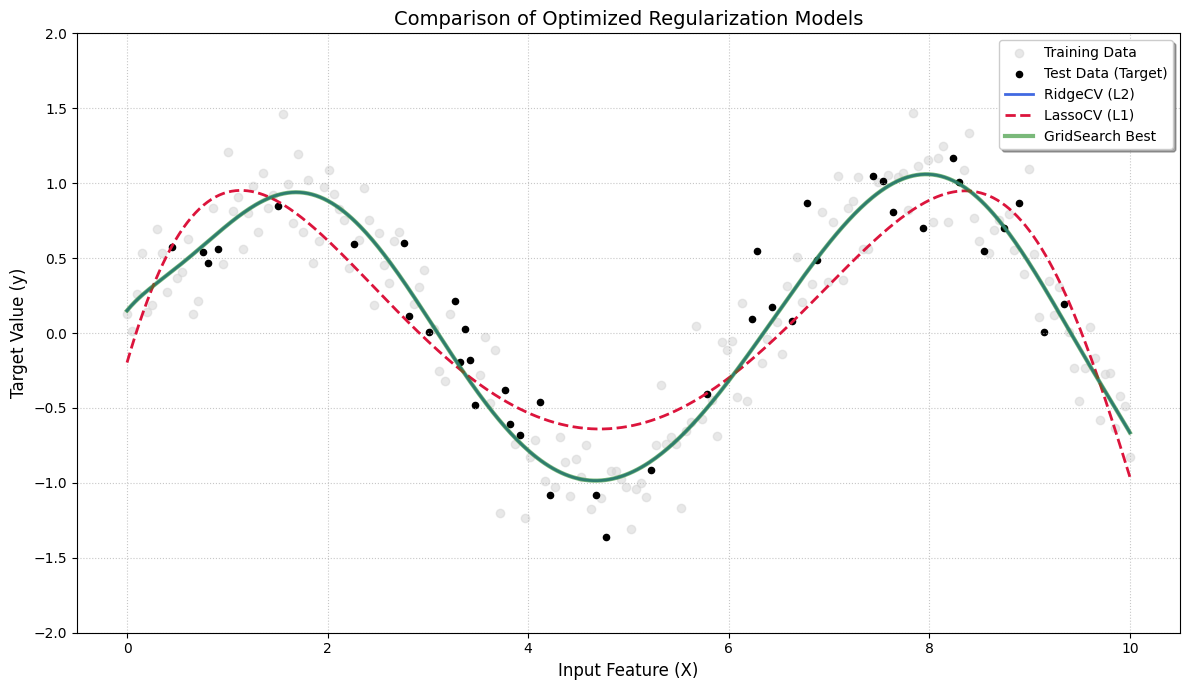

In [25]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge, Lasso, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline

# 1. Setup Data
np.random.seed(42)
X = np.linspace(0, 10, 200).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(scale=0.25, size=X.shape[0])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

alphas = np.logspace(-6, 3, 20)
results_list = []

# --- Method A: RidgeCV ---
ridge_pipe = make_pipeline(StandardScaler(), PolynomialFeatures(degree=10), RidgeCV(alphas=alphas, cv=5))
ridge_pipe.fit(X_train, y_train)

# --- Method B: LassoCV (Clean) ---
lasso_pipe = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=10),
    LassoCV(alphas=alphas, cv=5, max_iter=200000, tol=0.1, selection='random')
)
lasso_pipe.fit(X_train, y_train)

# --- Method C: GridSearchCV ---
full_pipe = make_pipeline(StandardScaler(), PolynomialFeatures(), Ridge())
param_grid = {'polynomialfeatures__degree': [2, 5, 8, 10], 'ridge__alpha': alphas}
grid_search = GridSearchCV(full_pipe, param_grid, cv=5)
grid_search.fit(X_train, y_train)

# 2. Results DataFrame
for name, model in [("RidgeCV", ridge_pipe), ("LassoCV", lasso_pipe), ("GridSearchCV", grid_search)]:
    mse = mean_squared_error(y_test, model.predict(X_test))
    results_list.append({"Method": name, "Test MSE": mse})

print("\n--- FINAL CLEAN RESULTS ---")
print(pd.DataFrame(results_list))

# 3. GRAPHIC FIX: Plotting Section
# We generate a smooth line of points to visualize the curves
X_range = np.linspace(0, 10, 500).reshape(-1, 1)

plt.figure(figsize=(12, 7))

# Plot the original data points
plt.scatter(X_train, y_train, color='lightgray', alpha=0.5, label='Training Data')
plt.scatter(X_test, y_test, color='black', s=20, label='Test Data (Target)')

# Plot the predicted curves
plt.plot(X_range, ridge_pipe.predict(X_range), color='royalblue', lw=2, label='RidgeCV (L2)')
plt.plot(X_range, lasso_pipe.predict(X_range), color='crimson', lw=2, linestyle='--', label='LassoCV (L1)')
plt.plot(X_range, grid_search.predict(X_range), color='forestgreen', lw=3, alpha=0.6, label='GridSearch Best')

# Formatting the graphic
plt.title('Comparison of Optimized Regularization Models', fontsize=14)
plt.xlabel('Input Feature (X)', fontsize=12)
plt.ylabel('Target Value (y)', fontsize=12)
plt.ylim(-2, 2) # Focus on the sine wave range
plt.legend(frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.7)

# FORCE RENDER
plt.tight_layout()
plt.show()

<a id="bonus-section-10-extra-marks"></a>

## Bonus Section (**10% extra marks** — complete **all 5** for full bonus)


[↑ Back to top](#toc)

<a id="conclusion"></a>

## Conclusion

# Final Reflection and Conclusion

### 1. Linear Failure and Nonlinearity
Standard linear regression failed because it can only model straight-line relationships (first-order polynomials). Since the target data followed a periodic sine wave, it was impossible for a simple line to minimize the error. The **Polynomial Basis Expansion** fixed this by projecting the single input $x$ into a higher-dimensional space ($x^1$ through $x^{10}$), allowing the linear model to fit a complex, nonlinear curve to the data.

### 2. Overfitting Symptoms and Detection
The primary symptoms of **overfitting** were the "ill-conditioned matrix" warnings and the massive, oscillating magnitudes of the coefficients in the unregularized model. I detected this by monitoring the **Train-Test Split**. While the training error was extremely low, the model's inability to generalize to the unseen test data resulted in a much higher Test MSE, indicating that the model was "memorizing" the noise rather than learning the sine wave.

### 3. Regularization Comparison
The three methods differ significantly in their approach to penalizing model complexity:
* **Ridge (L2):** Adds a penalty proportional to the *square* of the coefficients ($\alpha \sum w^2$). This shrinks coefficients toward zero but keeps all features, resulting in a "dense" but stable model.
* **Lasso (L1):** Adds a penalty proportional to the *absolute value* of the coefficients ($\alpha \sum |w|$). This produces **sparsity** by forcing less important features to exactly zero, effectively performing automatic feature selection.
* **Elastic Net:** A hybrid approach that combines both L1 and L2 penalties ($l1\_ratio$). it is particularly useful when features are highly correlated, as it balances sparsity with the stability of Ridge.

### 4. The Importance of Cross-Validation
**Cross-validation** is preferable to repeated test-set evaluation because it prevents **data leakage**. If I tune my hyperparameters ($\alpha$ or degree) based purely on the test set, I am indirectly "leaking" information from the test set into the training process. Cross-validation uses multiple internal folds to find the best parameters, ensuring the final model is truly robust and generalizable.

### 5. Real-World Caution
A major real-world caution when using high-degree polynomials is the risk of **numerical instability**. Without **Standard Scaling**, the difference between $x^1$ and $x^{10}$ becomes astronomically large (e.g., $10$ vs $10,000,000,000$), leading to floating-point errors and convergence failures. Furthermore, without **Regularization**, these models become extremely sensitive to outliers, where a single bad data point can wildly distort the entire prediction curve.

[↑ Back to top](#toc)